# 🕸️ Yoğunluk Tabanlı Kümeleme — DBSCAN & HDBSCAN / Density-Based Clustering — DBSCAN & HDBSCAN

**🇹🇷 Türkçe:**
Bu notebook, sentetik bir "şehir içi yaya konumları" veri setinde (`x_position`, `y_position`, 500 satır) **DBSCAN** ve **HDBSCAN** algoritmalarını karşılaştırıyor. Veri setinde gerçek küme etiketleri (`true_cluster`) de bulunuyor, ancak bunlar sadece görsel doğrulama için kullanılıyor — kümeleme algoritmalarının kendisi hiçbir etiket görmeden çalışıyor.

Odak noktası: iki algoritmanın varsayılan parametrelerle nasıl davrandığını görmek, ardından her biri için **ızgara araması (grid search)** ile hiperparametre taraması yapıp **silüet skoru (silhouette score)** ile en iyi kombinasyonu bulmak.

**🇬🇧 English:**
This notebook compares **DBSCAN** and **HDBSCAN** on a synthetic "urban pedestrian locations" dataset (`x_position`, `y_position`, 500 rows). The dataset also ships with ground-truth cluster labels (`true_cluster`), but these are used only for visual validation — the clustering algorithms themselves never see any label.

The focus: see how both algorithms behave with default parameters, then run a **grid search** over hyperparameters for each and use the **silhouette score** to find the best combination.

## 📦 0. Kütüphaneler / Imports

**🇹🇷 Türkçe:**
Veri işleme (`pandas`, `numpy`) ve görselleştirme (`matplotlib`, `seaborn`) için gerekli kütüphaneler yükleniyor.

**🇬🇧 English:**
Loading the libraries needed for data handling (`pandas`, `numpy`) and visualization (`matplotlib`, `seaborn`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📥 1. Veri Setini Yükleme ve Etiketi Ayırma / Load the Dataset & Set the Label Aside

**🇹🇷 Türkçe:**
`28-urban_pedestrian_locations_with_labels.csv` okunuyor: 500 nokta, iki koordinat kolonu (`x_position`, `y_position`) ve bir de `true_cluster` kolonu. `true_cluster` **gerçek** kümeleri gösteriyor, ama gerçek dünyada kümeleme yapılırken böyle bir etiket elde olmaz — bu yüzden hemen `drop` ediliyor ve sadece görsel karşılaştırma için ileride tekrar okunacak.

**🇬🇧 English:**
`28-urban_pedestrian_locations_with_labels.csv` is loaded: 500 points, two coordinate columns (`x_position`, `y_position`), and a `true_cluster` column. `true_cluster` shows the **actual** clusters, but in a real clustering problem you wouldn't have such a label — so it's dropped right away, and only re-read later for visual comparison.

In [2]:
df = pd.read_csv("../../Data/28-urban_pedestrian_locations_with_labels.csv")

In [3]:
df.head()

,x_position,y_position,true_cluster
0,0.830586,-0.447733,1
1,0.701678,0.816918,0
2,1.022080,-0.492571,1
3,-0.316765,0.953438,0
4,0.293226,1.057185,0


In [4]:
df = df.drop("true_cluster", axis=1)

## 📊 2. Ham Veri Görselleştirmesi / Raw Data Visualization

**🇹🇷 Türkçe:**
`x_position` ve `y_position` bir saçılım grafiğinde çiziliyor — etiketsiz haliyle, sadece noktaların uzamsal dağılımına bakarak kaç doğal grup görünüyor sorusuna ilk sezgisel cevap aranıyor.

**🇬🇧 English:**
`x_position` and `y_position` are plotted on a scatter plot — unlabeled, just looking at the spatial spread of the points to get a first visual sense of how many natural groups there are.

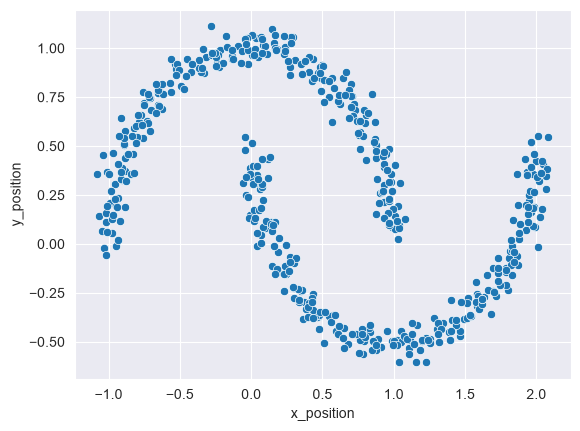

In [5]:
sns.scatterplot(data=df, x="x_position", y="y_position")
plt.show()

## 🔍 3. Veri Yapısı / Data Structure

**🇹🇷 Türkçe:**
`info()` ile 500 satır, iki `float64` kolon ve eksik değer olmadığı doğrulanıyor.

**🇬🇧 English:**
`info()` confirms 500 rows, two `float64` columns, and no missing values.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   x_position  500 non-null    float64
 1   y_position  500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


## ⚖️ 4. Özellik Ölçekleme / Feature Scaling

**🇹🇷 Türkçe:**
DBSCAN ve HDBSCAN, noktalar arası uzaklığa (varsayılan olarak Öklid) dayanıyor; bu yüzden `StandardScaler` ile her iki kolon da ortalaması 0, standart sapması 1 olacak şekilde standardize ediliyor. Burada eğitim/test ayrımı yapılmıyor çünkü bu tamamen keşifsel bir kümeleme egzersizi — tüm veri tek seferde ölçekleniyor.

**🇬🇧 English:**
DBSCAN and HDBSCAN both rely on distance between points (Euclidean by default), so `StandardScaler` standardizes both columns to mean 0, std 1. There's no train/test split here since this is a purely exploratory clustering exercise — the whole dataset is scaled at once.

In [7]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [8]:
X_scaled=scaler.fit_transform(df)

## 🧩 5. DBSCAN — Varsayılan Parametreler / DBSCAN with Default Parameters

**🇹🇷 Türkçe:**
`DBSCAN()` hiçbir parametre verilmeden (varsayılan `eps=0.5`, `min_samples=5` ile) ölçeklenmiş veri üzerinde eğitiliyor. `dbscan.labels_` her noktaya atanan küme numarasını veriyor (`-1` gürültü/outlier anlamına gelir, ama burada hiç `-1` görünmüyor — tüm noktalar 0 ya da 1 kümesine düşüyor).

**🇬🇧 English:**
`DBSCAN()` is fit on the scaled data with no parameters given (defaults: `eps=0.5`, `min_samples=5`). `dbscan.labels_` gives the cluster number assigned to each point (`-1` would mean noise/outlier, but none appear here — every point falls into cluster 0 or 1).

In [9]:
from sklearn.cluster import DBSCAN

In [10]:
dbscan = DBSCAN()

In [11]:
dbscan.fit(X_scaled)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.5
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",5
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
"components_ components_: ndarray of shape (n_core_samples, n_features)Copy of each core sample found by training.","ndarray[float64](500, 2)","[[ 0.38,-1.4 ], [ 0.23, 1.14], [ 0.6 ,-1.49], ..., [ 0.1 ,-1.24], [ 1.28,-1.07], [-0.32, 1.63]]"
"core_sample_indices_ core_sample_indices_: ndarray of shape (n_core_samples,)Indices of core samples.","ndarray[int64](500,)","[ 0, 1, 2,...,497,498,499]"


In [12]:
dbscan.labels_

array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

## 🔁 6. Ölçeklenmiş Veriyi DataFrame'e Çevirip Sonucu Görselleştirme / Convert Scaled Data Back to a DataFrame & Visualize

**🇹🇷 Türkçe:**
`X_scaled` bir NumPy dizisi olduğu için, `x`/`y` kolon adlarıyla saçılım grafiği çizebilmek adına tekrar bir DataFrame'e çevriliyor. Ardından noktalar `dbscan.labels_`'a göre renklendirilerek çiziliyor — varsayılan parametrelerle DBSCAN'in iki kümeyi net şekilde ayırdığı görülüyor.

**🇬🇧 English:**
Since `X_scaled` is a NumPy array, it's converted back into a DataFrame with the `x`/`y` column names so it can be plotted with named axes. The points are then colored by `dbscan.labels_` — with default parameters, DBSCAN clearly separates two clusters.

In [13]:
X_scaled = pd.DataFrame(X_scaled, columns = ["x_position", "y_position"])

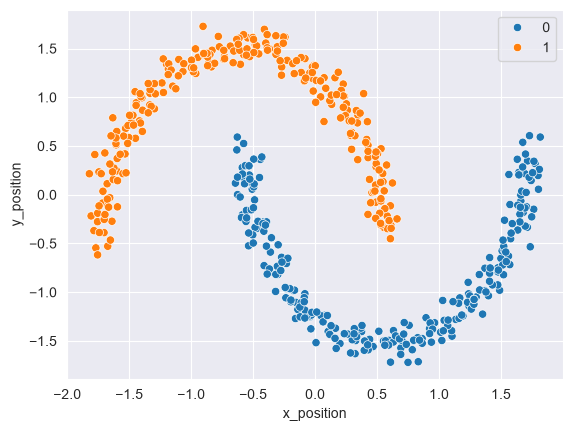

In [14]:
sns.scatterplot(data=X_scaled, x="x_position", y="y_position", hue=dbscan.labels_)
plt.show()

## 🎯 7. Gerçek Kümelerle Karşılaştırma / Comparing Against the Ground-Truth Clusters

**🇹🇷 Türkçe:**
`true_cluster` kolonunu içeren orijinal CSV tekrar okunuyor ve noktalar bu kez gerçek etikete göre renklendiriliyor. Bu, sadece görsel bir doğrulama adımı: DBSCAN'in yukarıda ürettiği iki kümenin gerçek gruplarla ne kadar örtüştüğünü göz kararıyla kontrol etmeye yarıyor — model eğitiminin bir parçası değil.

**🇬🇧 English:**
The original CSV (with the `true_cluster` column) is read again, and the points are colored by the real label this time. This is purely a visual sanity check — comparing by eye how well DBSCAN's two clusters above line up with the actual groups — not part of model training.

In [15]:
df = pd.read_csv("../../Data/28-urban_pedestrian_locations_with_labels.csv")

In [16]:
df.columns

Index(['x_position', 'y_position', 'true_cluster'], dtype='str')

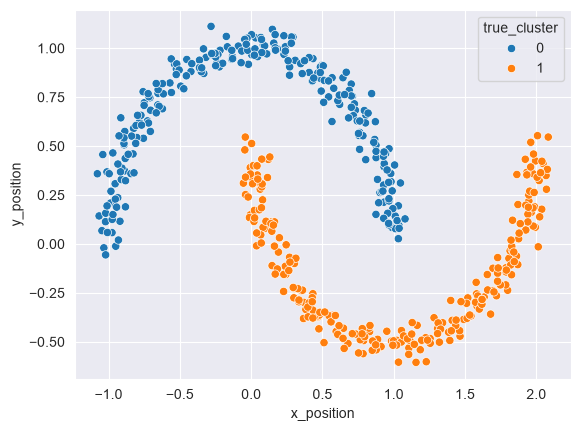

In [17]:
sns.scatterplot(data=df, x="x_position", y="y_position", hue="true_cluster")
plt.show()

## 🛠️ 8. DBSCAN için Hiperparametre Taraması / Hyperparameter Search for DBSCAN

**🇹🇷 Türkçe:**
`eps` (0.1–0.6) ve `min_samples` (4–6) için tüm kombinasyonlar deneniyor; her biri için `silhouette_score` hesaplanıyor (tek kümeye çöken kombinasyonlar `len(set(labels)) <= 1` koşuluyla atlanıyor). Sonuçlar silüet skoruna göre sıralanıyor.

**Gözlem:** `eps >= 0.2` olan **her** kombinasyon aynı silüet skorunu (0.389338) ve aynı küme sayısını (2) veriyor — yani bu aralıkta DBSCAN, `eps`/`min_samples` tam olarak ne seçilirse seçilsin hep aynı iki kümeye yakınsıyor. Sadece `eps=0.1` (komşuluk yarıçapı çok dar) farklı davranıyor: veri 9-18 küçük parçaya bölünüyor ve skor belirgin şekilde düşüyor (0.146–0.287). Bu, verinin gerçekten belirgin iki yoğun bölgeden oluştuğunu ve DBSCAN'in bu aralıkta parametre seçimine karşı oldukça dayanıklı (robust) olduğunu gösteriyor.

**🇬🇧 English:**
Every combination of `eps` (0.1–0.6) and `min_samples` (4–6) is tried; `silhouette_score` is computed for each (combinations that collapse to a single cluster are skipped via `len(set(labels)) <= 1`). Results are sorted by silhouette score.

**Observation:** **Every** combination with `eps >= 0.2` gives the exact same silhouette score (0.389338) and the same number of clusters (2) — meaning DBSCAN converges to the same two clusters regardless of the exact `eps`/`min_samples` chosen in that range. Only `eps=0.1` (too narrow a neighborhood radius) behaves differently: the data splits into 9–18 small fragments and the score drops noticeably (0.146–0.287). This shows the data genuinely consists of two well-separated dense regions, and that DBSCAN is quite robust to parameter choice in this range.

In [18]:
eps_values = [0.1,0.2,0.3,0.4,0.5,0.6]
min_samples_values = [4,5,6]

In [19]:
from sklearn.metrics import silhouette_score

In [20]:
results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
        labels = db.labels_

        if len(set(labels)) <= 1:
            continue
        
        silhouette = silhouette_score(X_scaled, labels)
        
        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'Silhouette': silhouette,
            'n_clusters': len(set(labels)) - (1 if -1 in labels else 0)
        })


results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Silhouette', ascending=False)

In [21]:
results_df

,eps,min_samples,Silhouette,n_clusters
4,0.2,5,0.389338,2
3,0.2,4,0.389338,2
14,0.5,6,0.389338,2
11,0.4,6,0.389338,2
5,0.2,6,0.389338,2
6,0.3,4,0.389338,2
8,0.3,6,0.389338,2
7,0.3,5,0.389338,2
9,0.4,4,0.389338,2
10,0.4,5,0.389338,2


## 🌲 9. HDBSCAN — Varsayılan Parametreler / HDBSCAN with Default Parameters

**🇹🇷 Türkçe:**
`HDBSCAN()`, DBSCAN'in aksine sabit bir `eps` istemiyor — küme yoğunluk eşiğini veriden otomatik olarak çıkarıyor. Varsayılan haliyle ölçeklenmiş veriye uygulanıyor; `labels_` ve görselleştirme, DBSCAN ile bulunan iki kümeyle neredeyse birebir aynı sonucu veriyor.

**Not:** Çalıştırma sırasında görülen `FutureWarning: The default value of copy will change...` uyarısı, scikit-learn'in gelecekteki bir sürümünde `copy` parametresinin varsayılanının değişeceğini bildiren zararsız bir kütüphane uyarısıdır; sonucu etkilemiyor.

**🇬🇧 English:**
Unlike DBSCAN, `HDBSCAN()` doesn't need a fixed `eps` — it infers the density threshold from the data automatically. It's applied with default settings on the scaled data; `labels_` and the visualization give an almost identical result to DBSCAN's two clusters.

**Note:** The `FutureWarning: The default value of copy will change...` seen during the run is a harmless scikit-learn library warning about a future change to the `copy` parameter's default — it doesn't affect the result.

In [22]:
from sklearn.cluster import HDBSCAN

In [23]:
hdbscan = HDBSCAN()

In [24]:
hdbscan.fit(X_scaled)

C:\Users\efeka\PycharmProjects\PythonProject1\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


,"min_cluster_size min_cluster_size: int, default=5The minimum number of samples in a group for that group to beconsidered a cluster; groupings smaller than this size will be leftas noise.",5
,"min_samples min_samples: int, default=NoneThe parameter `k` used to calculate the distance between a point`x_p` and its k-th nearest neighbor.When `None`, defaults to `min_cluster_size`.",None
,"cluster_selection_epsilon cluster_selection_epsilon: float, default=0.0A distance threshold. Clusters below this value will be merged.See [5]_ for more information.",0.0
,"max_cluster_size max_cluster_size: int, default=NoneA limit to the size of clusters returned by the `""eom""` clusterselection algorithm. There is no limit when `max_cluster_size=None`.Has no effect if `cluster_selection_method=""leaf""`.",None
,"metric metric: str or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array.- If metric is a string or callable, it must be one of the options allowed by :func:`~sklearn.metrics.pairwise_distances` for its metric parameter.- If metric is ""precomputed"", X is assumed to be a distance matrix and must be square.",'euclidean'
,"metric_params metric_params: dict, default=NoneArguments passed to the distance metric.",None
,"alpha alpha: float, default=1.0A distance scaling parameter as used in robust single linkage.See [3]_ for more information.",1.0
,"algorithm algorithm: {""auto"", ""brute"", ""kd_tree"", ""ball_tree""}, default=""auto""Exactly which algorithm to use for computing core distances; By defaultthis is set to `""auto""` which attempts to use a:class:`~sklearn.neighbors.KDTree` tree if possible, otherwise it usesa :class:`~sklearn.neighbors.BallTree` tree. Both `""kd_tree""` and`""ball_tree""` algorithms use the:class:`~sklearn.neighbors.NearestNeighbors` estimator.If the `X` passed during `fit` is sparse or `metric` is invalid forboth :class:`~sklearn.neighbors.KDTree` and:class:`~sklearn.neighbors.BallTree`, then it resolves to use the`""brute""` algorithm.",'auto'
,"leaf_size leaf_size: int, default=40Leaf size for trees responsible for fast nearest neighbour queries whena KDTree or a BallTree are used as core-distance algorithms. A largedataset size and small `leaf_size` may induce excessive memory usage.If you are running out of memory consider increasing the `leaf_size`parameter. Ignored for `algorithm=""brute""`.",40
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel to calculate distances.`None` means 1 unless in a :obj:`joblib.parallel_backend` context.`-1` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"cluster_selection_method cluster_selection_method: {""eom"", ""leaf""}, default=""eom""The method used to select clusters from the condensed tree. Thestandard approach for HDBSCAN* is to use an Excess of Mass (`""eom""`)algorithm to find the most persistent clusters. Alternatively you caninstead select the clusters at the leaves of the tree -- this providesthe most fine grained and homogeneous clusters.",'eom'


In [25]:
hdbscan.labels_

array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

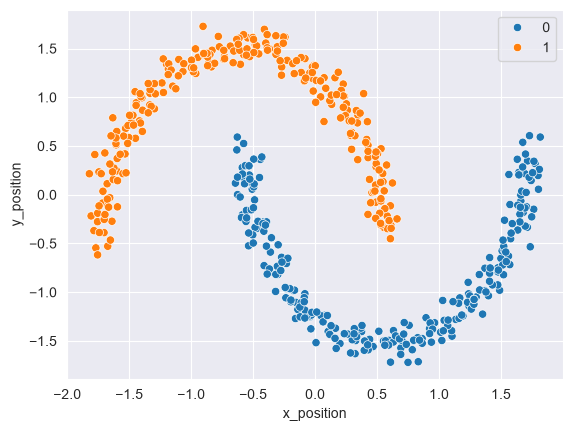

In [26]:
sns.scatterplot(data=X_scaled, x="x_position", y="y_position", hue=hdbscan.labels_)
plt.show()

## 🛠️ 10. HDBSCAN için Hiperparametre Taraması / Hyperparameter Search for HDBSCAN

**🇹🇷 Türkçe:**
Bu kez `min_cluster_size` (3, 5, 7, 10) ve `min_samples` (`None`, 3, 5, 7) kombinasyonları taranıyor, aynı `silhouette_score` mantığıyla.

**Gözlem:** `min_cluster_size >= 5` olan tüm kombinasyonlar (ve `min_cluster_size=3` ile `min_samples` 5 veya 7) yine aynı skoru (0.389338, 2 küme) veriyor — DBSCAN taramasındakiyle birebir aynı en iyi sonuç. Sadece en agresif ayar olan `min_cluster_size=3, min_samples∈{None,3}` farklı davranıyor: veri 30 küçük parçaya bölünüyor ve silüet skoru **negatife** düşüyor (-0.001274) — bu, kümelerin birbirinden neredeyse hiç ayrılmadığı, yani aşırı-parçalanmış (over-segmented) bir sonuca işaret ediyor. Sonuç olarak hem DBSCAN hem HDBSCAN, makul parametrelerle bu veri setinde aynı iki kümeye yakınsıyor; varsayılan parametreler bile burada yeterliydi.

**🇬🇧 English:**
This time `min_cluster_size` (3, 5, 7, 10) and `min_samples` (`None`, 3, 5, 7) combinations are swept, with the same `silhouette_score` logic.

**Observation:** Every combination with `min_cluster_size >= 5` (plus `min_cluster_size=3` with `min_samples` 5 or 7) gives the same score again (0.389338, 2 clusters) — identical to the best result from the DBSCAN sweep. Only the most aggressive setting, `min_cluster_size=3, min_samples∈{None,3}`, behaves differently: the data splits into 30 tiny fragments and the silhouette score drops **negative** (-0.001274) — indicating an over-segmented result where clusters barely separate from each other. In the end, both DBSCAN and HDBSCAN converge on the same two clusters for this dataset with any reasonable parameters; even the defaults were good enough here.

In [27]:
min_cluster_sizes = [3, 5, 7, 10]
min_samples = [None, 3, 5, 7]

In [28]:
results = []

for min_cluster in min_cluster_sizes:
    for min_sample in min_samples:
        hdb = HDBSCAN(min_cluster_size=min_cluster, min_samples=min_sample).fit(X_scaled)
        labels = hdb.labels_

        if len(set(labels)) <= 1:
            continue
        
        silhouette = silhouette_score(X_scaled, labels)
        
        results.append({
            'min_cluster_size': min_cluster,
            'min_samples': min_sample,
            'Silhouette': silhouette,
            'n_clusters': len(set(labels)) - (1 if -1 in labels else 0)
        })


results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Silhouette', ascending=False)

C:\Users\efeka\PycharmProjects\PythonProject1\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
C:\Users\efeka\PycharmProjects\PythonProject1\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
C:\Users\efeka\PycharmProjects\PythonProject1\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
C:\Users\efeka\PycharmProjects\PythonProject1\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value 

In [29]:
results_df

,min_cluster_size,min_samples,Silhouette,n_clusters
3,3,7.0,0.389338,2
2,3,5.0,0.389338,2
5,5,3.0,0.389338,2
4,5,NaN,0.389338,2
6,5,5.0,0.389338,2
7,5,7.0,0.389338,2
9,7,3.0,0.389338,2
8,7,NaN,0.389338,2
12,10,NaN,0.389338,2
13,10,3.0,0.389338,2
